# Perceptron Multi-Couches (MLP) — Prédiction du prix médian immobilier

**Modèle** : Multi-Layer Perceptron (régression)

$$h^{(l)} = \text{ReLU}(W^{(l)} h^{(l-1)} + b^{(l)}), \quad \hat{y} = W^{(out)} h^{(L)} + b^{(out)}$$

**Pipeline** :
1. Analyse de colinéarité → suppression des features redondantes
2. Train/test split (70/30)
3. Entraînement MLP (Adam, MSE loss, 2 couches cachées)
4. Évaluation (MAE, RMSE, MAPE, R²)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

df = pd.read_csv('./datasets/amputed_normalized_housing_data.csv')
print(f"Shape : {df.shape}")
df.head()

Shape : (17601, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-1.315977,0.995320,1.83728,-0.622220,-1.156299,-1.161352,-1.168233,2.620165,352100.0,1.300935
1,-1.320967,0.995320,1.83728,-0.799883,-0.953182,-1.058970,-0.964205,1.477758,341300.0,1.300935
2,-1.320967,0.995320,1.83728,-0.474934,-0.750065,-1.047410,-0.769893,0.206130,342200.0,1.300935
3,-1.320967,0.995320,1.83728,-1.126674,-1.052484,-1.298413,-1.090508,0.341013,269700.0,1.300935
4,-1.320967,0.990705,1.83728,0.360912,0.193300,-0.173855,0.468851,0.073723,299200.0,1.300935


## 1. Analyse de colinéarité

Deux features fortement corrélées portent la même information → on supprime celle qui corrèle le moins avec la cible.

Seuil : $|r| > 0.8$

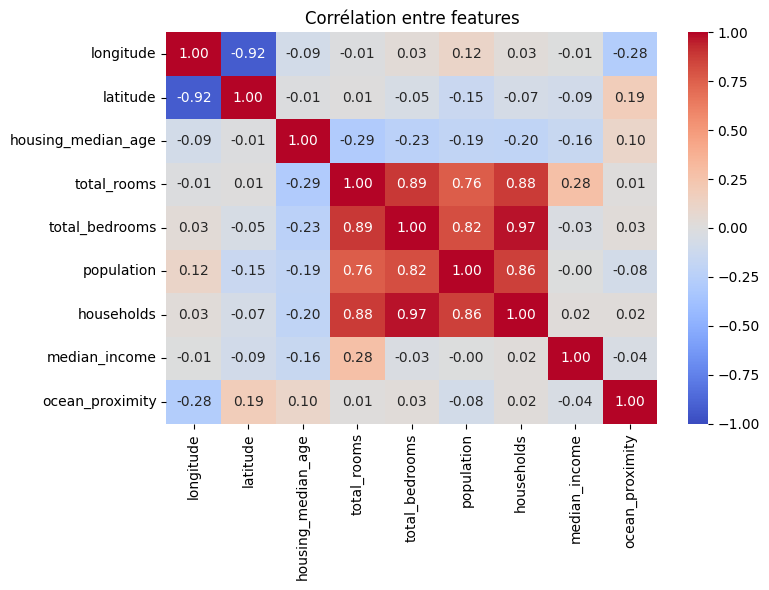


Paires avec |r| > 0.8 :
  longitude ↔ latitude : r = -0.923
  total_rooms ↔ total_bedrooms : r = 0.888
  total_rooms ↔ households : r = 0.880
  total_bedrooms ↔ population : r = 0.820
  total_bedrooms ↔ households : r = 0.971
  population ↔ households : r = 0.860


In [2]:
target = 'median_house_value'
features = [c for c in df.columns if c != target]

# Matrice de corrélation entre features
corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Corrélation entre features')
plt.tight_layout()
plt.show()

# Paires fortement corrélées (|r| > 0.8)
threshold = 0.8
pairs = []
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        if abs(corr.iloc[i, j]) > threshold:
            pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))

print(f"\nPaires avec |r| > {threshold} :")
for a, b, r in pairs:
    print(f"  {a} ↔ {b} : r = {r:.3f}")

In [3]:
# Pour chaque paire colinéaire, on garde celle qui corrèle le mieux avec la cible
target_corr = df[features].corrwith(df[target]).abs()

to_drop = set()
for a, b, r in pairs:
    drop = a if target_corr[a] < target_corr[b] else b
    to_drop.add(drop)
    print(f"  {a} (|r_target|={target_corr[a]:.3f}) vs {b} (|r_target|={target_corr[b]:.3f}) → drop {drop}")

features_clean = [f for f in features if f not in to_drop]
print(f"\nFeatures conservées ({len(features_clean)}) : {features_clean}")
print(f"Features supprimées ({len(to_drop)}) : {to_drop}")

  longitude (|r_target|=0.042) vs latitude (|r_target|=0.158) → drop longitude
  total_rooms (|r_target|=0.183) vs total_bedrooms (|r_target|=0.091) → drop total_bedrooms
  total_rooms (|r_target|=0.183) vs households (|r_target|=0.118) → drop households
  total_bedrooms (|r_target|=0.091) vs population (|r_target|=0.019) → drop population
  total_bedrooms (|r_target|=0.091) vs households (|r_target|=0.118) → drop total_bedrooms
  population (|r_target|=0.019) vs households (|r_target|=0.118) → drop population

Features conservées (5) : ['latitude', 'housing_median_age', 'total_rooms', 'median_income', 'ocean_proximity']
Features supprimées (4) : {'households', 'total_bedrooms', 'population', 'longitude'}


## 2. Train / Test split (70/30)

In [4]:
X = df[features_clean].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Train : 12320 samples (70%)
Test  : 5281 samples (30%)


## 3. Perceptron Multi-Couches (MLPRegressor)

Architecture : **5 → 64 → 32 → 1** (2 couches cachées, activation ReLU, optimiseur Adam)

$$h_1 = \text{ReLU}(W_1 x + b_1) \quad h_2 = \text{ReLU}(W_2 h_1 + b_2) \quad \hat{y} = W_3 h_2 + b_3$$

$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Convergé en 271 epochs
Architecture : [5] → [64, 32] → [1]
Nombre de poids : 2497


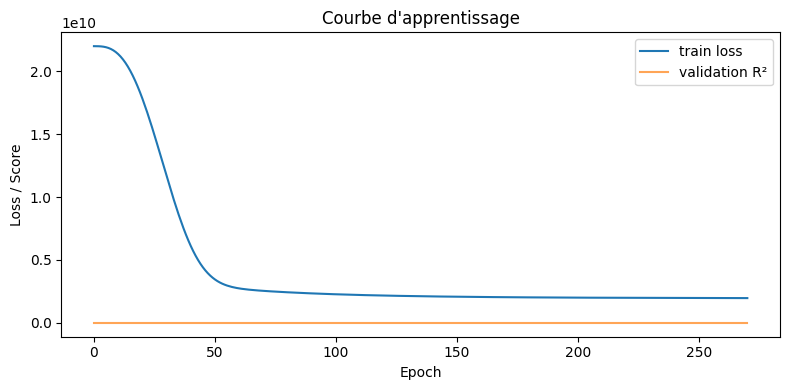

In [5]:
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)

model.fit(X_train, y_train)
print(f"Convergé en {model.n_iter_} epochs")
print(f"Architecture : {[X_train.shape[1]]} → {list(model.hidden_layer_sizes)} → [1]")
print(f"Nombre de poids : {sum(c.size for c in model.coefs_) + sum(b.size for b in model.intercepts_)}")

# Courbe de loss
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_, label='train loss')
if model.validation_scores_:
    plt.plot(model.validation_scores_, label='validation R²', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss / Score')
plt.title('Courbe d\'apprentissage')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Évaluation — Métriques à différentes échelles

| Métrique | Formule | Échelle | Interprétation |
|----------|---------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ | Dollars ($) | Erreur moyenne absolue — robuste aux outliers |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Dollars ($) | Pénalise les grosses erreurs (quadratique) |
| **MAPE** | $\frac{100}{n}\sum\left\|\frac{y_i - \hat{y}_i}{y_i}\right\|$ | Pourcentage (%) | Erreur relative — indépendante de l'échelle |
| **R²** | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Sans unité [0,1] | Part de variance expliquée par le modèle |

       MAE ($)  RMSE ($)  MAPE (%)   R²
Train 45839.64  62840.88     28.24 0.56
Test  46288.21  63958.31     27.98 0.55


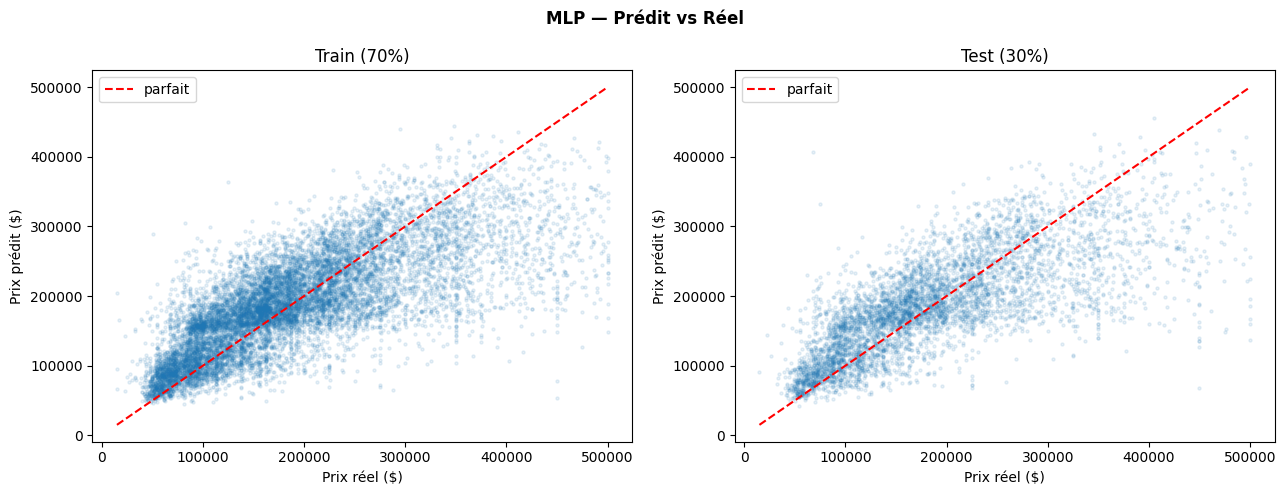

In [6]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

metrics = {}
for name, y_true, y_pred in [('Train', y_train, y_pred_train), ('Test', y_test, y_pred_test)]:
    metrics[name] = {
        'MAE ($)': mean_absolute_error(y_true, y_pred),
        'RMSE ($)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'R²': r2_score(y_true, y_pred),
    }

metrics_df = pd.DataFrame(metrics).T
print(metrics_df.to_string(float_format=lambda x: f'{x:.2f}'))

# Scatter plot prédit vs réel
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, y_true, y_pred) in zip(axes, [('Train (70%)', y_train, y_pred_train), ('Test (30%)', y_test, y_pred_test)]):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=1.5, label='parfait')
    ax.set_xlabel('Prix réel ($)')
    ax.set_ylabel('Prix prédit ($)')
    ax.set_title(f'{name}')
    ax.legend()
plt.suptitle('MLP — Prédit vs Réel', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Architecture du MLP

Visualisation du réseau **5 → 64 → 32 → 1** avec les couches cachées.

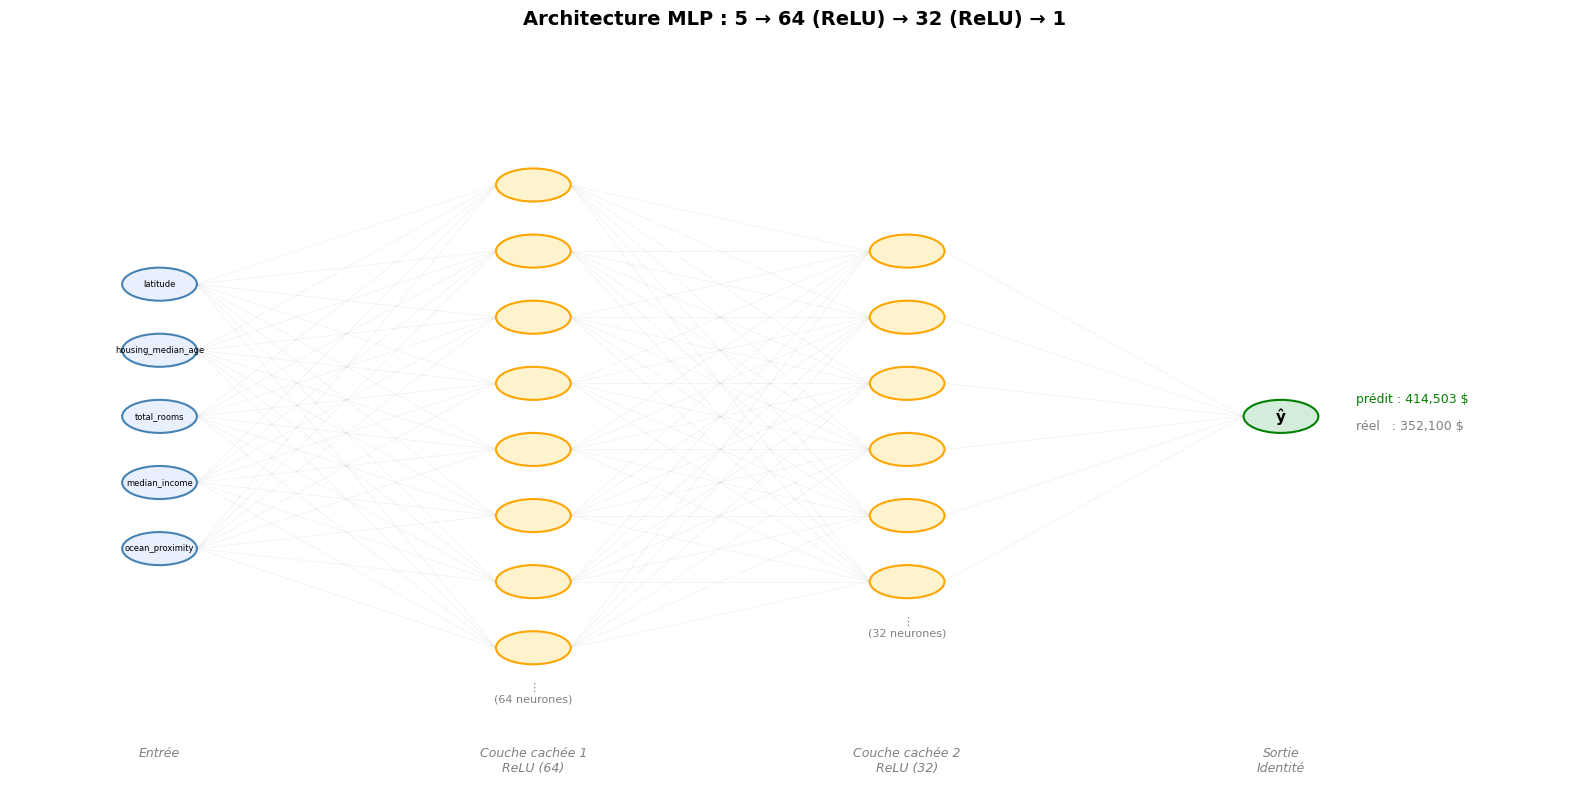

In [7]:
import matplotlib.patches as mpatches

layer_sizes = [len(features_clean), 64, 32, 1]
layer_labels = ['Entrée', 'Couche cachée 1\nReLU (64)', 'Couche cachée 2\nReLU (32)', 'Sortie\nIdentité']
layer_colors = ['#e8f0fe', '#fff3cd', '#fff3cd', '#d4edda']
layer_edge = ['steelblue', 'orange', 'orange', 'green']
max_display = [layer_sizes[0], 8, 6, 1]  # cap displayed neurons for readability

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')
ax.set_xlim(-0.5, len(layer_sizes) * 2.5)
ax.set_ylim(-1, max(max_display) + 2)
ax.set_title('Architecture MLP : 5 → 64 (ReLU) → 32 (ReLU) → 1', fontsize=14, fontweight='bold', pad=20)

node_positions = []

for l, (size, display, label, fc, ec) in enumerate(zip(layer_sizes, max_display, layer_labels, layer_colors, layer_edge)):
    x = l * 2.5 + 0.5
    positions = []
    offset = (max(max_display) - display) / 2

    for i in range(display):
        y = offset + display - i
        circle = plt.Circle((x, y), 0.25, fc=fc, ec=ec, lw=1.5, zorder=5)
        ax.add_patch(circle)
        positions.append((x, y))

        # Label input neurons with feature names
        if l == 0:
            ax.text(x, y, features_clean[i], ha='center', va='center', fontsize=6, zorder=6)
        elif l == len(layer_sizes) - 1:
            ax.text(x, y, 'ŷ', ha='center', va='center', fontsize=11, fontweight='bold', zorder=6)

    # Show "..." if truncated
    if size > display:
        y_dots = offset + 0.3
        ax.text(x, y_dots, f'⋮\n({size} neurones)', ha='center', va='center', fontsize=8, color='gray')

    # Layer label
    ax.text(x, -0.5, label, ha='center', va='top', fontsize=9, fontstyle='italic', color='gray')

    node_positions.append(positions)

# Draw connections between layers (subsample for readability)
for l in range(len(node_positions) - 1):
    src = node_positions[l]
    dst = node_positions[l + 1]
    for sx, sy in src:
        for dx, dy in dst:
            ax.plot([sx + 0.25, dx - 0.25], [sy, dy], color='gray', alpha=0.12, lw=0.5, zorder=1)

# Sample prediction
sample = df[features_clean].iloc[0].values
sample_pred = model.predict(sample.reshape(1, -1))[0]
sample_target = df[target].iloc[0]
out_x, out_y = node_positions[-1][0]
ax.text(out_x + 0.5, out_y + 0.2, f'prédit : {sample_pred:,.0f} $', ha='left', fontsize=9, color='green')
ax.text(out_x + 0.5, out_y - 0.2, f'réel   : {sample_target:,.0f} $', ha='left', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

## 6. Export du modèle

On sauvegarde le modèle entraîné, le scaler (fitted sur les données nettoyées), et les métadonnées nécessaires pour prédire à partir de données brutes.

In [8]:
import joblib

joblib.dump(model, './models/mlp_model.joblib')
joblib.dump(features_clean, './models/model_features.joblib')
print("Modèle exporté → ./models/mlp_model.joblib")
print(f"Features utilisées : {features_clean}")

Modèle exporté → ./models/mlp_model.joblib
Features utilisées : ['latitude', 'housing_median_age', 'total_rooms', 'median_income', 'ocean_proximity']
